# Ensemble: ResNet50 + DenseNet121 + Swin Tiny
Triple ensemble, same working pattern as the other ensemble notebooks.

Both CNNs load directly with `load_model` (no legacy Keras needed for `Swin Tiny`). `Swin Tiny` is rebuilt from architecture + `load_weights`.

Run cells top to bottom (or Runtime → Run all).

## Cell 1 — Setup (installs + imports)

In [1]:
!pip install tfswin --no-deps -q


import os
import shutil
import zipfile
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.models import load_model
import tfswin  # must import before loading/rebuilding the Swin model
from tfswin import SwinTransformerTiny224
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import logging
tf.get_logger().setLevel('ERROR')
logging.getLogger('tensorflow').setLevel(logging.ERROR)

print("numpy:", np.__version__)
print("pandas:", pd.__version__)
print("TF_USE_LEGACY_KERAS:", os.environ.get("TF_USE_LEGACY_KERAS"))
print("All imports successful!")

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing backend dependencies ... done
  Preparing metadata (pyproject.toml) ... done
numpy: 2.0.2
pandas: 2.2.3
TF_USE_LEGACY_KERAS: None
All imports successful!


## Cell 2 — Drive mount

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Cell 3 — Restore test set (images + CSV)

In [3]:
split_zip_path = '/content/drive/MyDrive/split_dataset.zip'
csv_zip_path = '/content/drive/MyDrive/thesis_dataset_csv-20260716T043638Z-1-001.zip'

if not os.path.exists('/content/test'):
    shutil.copy(split_zip_path, '/content/split_dataset.zip')
    with zipfile.ZipFile('/content/split_dataset.zip', 'r') as zip_ref:
        zip_ref.extractall('/content/')

if not os.path.exists('/content/csv_data'):
    with zipfile.ZipFile(csv_zip_path, 'r') as zip_ref:
        zip_ref.extractall('/content/csv_data')

print("Test folder ready:", os.path.exists('/content/test'))

Test folder ready: True


## Cell 4 — Load test CSV, fix paths
This defines `class_names`, `label_to_index`, `true_labels` — required by later cells.

In [4]:
test_df = pd.read_csv('/content/csv_data/thesis_dataset_csv/test_data.csv')
test_df['filepath'] = test_df['filepath'].str.replace('/content/split_dataset', '/content')

print("Sample file exists:", os.path.exists(test_df['filepath'].iloc[0]))
print("Test samples:", len(test_df))

class_names = sorted(test_df['label'].unique())
num_classes = len(class_names)
label_to_index = {name: i for i, name in enumerate(class_names)}
true_labels = test_df['label'].map(label_to_index).values

print("Classes:", class_names)

Sample file exists: True
Test samples: 2538
Classes: ['Corn_Common_Rust', 'Corn_Gray_Leaf_Spot', 'Corn_Healthy', 'Corn_Leaf_Blight', 'Rice_Bacterial_Leaf_Blight', 'Rice_Brown_Spot', 'Rice_Healthy', 'Rice_Leaf_Blast', 'Wheat_Brown_Rust', 'Wheat_Healthy', 'Wheat_Loose_Smut', 'Wheat_Yellow_Rust']


## Cell 5 — Config

In [5]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
filepaths = test_df['filepath'].values

## Cell 6 — Build the loading function(s)
Swin Tiny needs raw `uint8` pixels. ResNet50, DenseNet121 take raw `float32` pixels in [0, 255] (normalization/`preprocess_input` baked into the model), so they share one dataset.

In [6]:
def load_uint8(filepath):
    img = tf.io.read_file(filepath)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.cast(tf.clip_by_value(img, 0, 255), tf.uint8)
    return img

def load_float32(filepath):
    img = tf.io.read_file(filepath)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, IMG_SIZE)
    return img  # stays float32, values 0-255

## Cell 7 — Build the test dataset(s)

In [7]:
def make_ds(load_fn):
    ds = tf.data.Dataset.from_tensor_slices(filepaths)
    ds = ds.map(load_fn, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds

test_ds_uint8 = make_ds(load_uint8)      # for Swin Tiny
test_ds_float32 = make_ds(load_float32)  # for ResNet50, DenseNet121

print("Datasets ready")

Datasets ready


## Cell 8 — Load all three trained models
Swin Tiny is rebuilt from architecture and then `load_weights`. ResNet50 and DenseNet121 load directly since their files live in your own Drive.

In [8]:
# --- ResNet50: extract from Drive zip backup, then load normally ---
resnet_zip_path = '/content/drive/MyDrive/thesis_resnet50_outputs-20260716T043630Z-1-001.zip'
print("Zip exists:", os.path.exists(resnet_zip_path))

if not os.path.exists('/content/resnet50_data'):
    with zipfile.ZipFile(resnet_zip_path, 'r') as zip_ref:
        zip_ref.extractall('/content/resnet50_data')

resnet_model_path = '/content/resnet50_data/thesis_resnet50_outputs/best_resnet50_model.keras'
print("Model file exists:", os.path.exists(resnet_model_path))

resnet_model = load_model(resnet_model_path)
print("ResNet50 loaded successfully")

Zip exists: True
Model file exists: True
ResNet50 loaded successfully


In [9]:
# --- DenseNet121: load directly from your Drive ---
densenet_model_path = '/content/drive/MyDrive/thesis_densenet121_outputs/best_densenet121_model.keras'
print("Model file exists:", os.path.exists(densenet_model_path))

densenet_model = load_model(densenet_model_path)
print("DenseNet121 loaded successfully")

Model file exists: True
DenseNet121 loaded successfully


In [10]:
# --- Swin Transformer Tiny: rebuild architecture, then load trained weights ---
swin_inputs = layers.Input(shape=(224, 224, 3), dtype='uint8')
swin_base = SwinTransformerTiny224(include_top=False)
x = swin_base(swin_inputs)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.4)(x)
swin_outputs = layers.Dense(num_classes, activation='softmax')(x)

swin_model = models.Model(swin_inputs, swin_outputs)
swin_model.load_weights('/content/drive/MyDrive/thesis_swintiny_outputs/best_swintiny_model.keras')
print("Swin model rebuilt and weights loaded!")

177485300/177485300 ━━━━━━━━━━━━━━━━━━━━ 14s 0us/step
Swin model rebuilt and weights loaded!


## Cell 8b — Sanity check: all three models still reproduce their known test accuracy

In [11]:
pred_resnet_check = resnet_model.predict(test_ds_float32, verbose=1)
acc_resnet_check = accuracy_score(true_labels, np.argmax(pred_resnet_check, axis=1))
print(f"ResNet50 test accuracy: {acc_resnet_check:.4f}")

pred_densenet_check = densenet_model.predict(test_ds_float32, verbose=1)
acc_densenet_check = accuracy_score(true_labels, np.argmax(pred_densenet_check, axis=1))
print(f"DenseNet121 test accuracy: {acc_densenet_check:.4f}")

pred_swin_check = swin_model.predict(test_ds_uint8, verbose=1)
acc_swin_check = accuracy_score(true_labels, np.argmax(pred_swin_check, axis=1))
print(f"Swin Tiny test accuracy: {acc_swin_check:.4f}")


80/80 ━━━━━━━━━━━━━━━━━━━━ 25s 200ms/step
ResNet50 test accuracy: 0.9795
80/80 ━━━━━━━━━━━━━━━━━━━━ 44s 309ms/step
DenseNet121 test accuracy: 0.9689
80/80 ━━━━━━━━━━━━━━━━━━━━ 48s 370ms/step
Swin Tiny test accuracy: 0.9842


## Cell 9 — Get predictions from each model (test set, reused for the ensemble below)

In [12]:
pred_resnet = pred_resnet_check      # already computed in the sanity check above
pred_densenet = pred_densenet_check      # already computed in the sanity check above
pred_swin = pred_swin_check      # already computed in the sanity check above

## Cell 10 — Ensemble (simple average) + accuracy comparison

In [13]:
ensemble_probs = (pred_resnet + pred_densenet + pred_swin) / 3.0
ensemble_preds = np.argmax(ensemble_probs, axis=1)

acc_resnet = accuracy_score(true_labels, np.argmax(pred_resnet, axis=1))
acc_densenet = accuracy_score(true_labels, np.argmax(pred_densenet, axis=1))
acc_swin = accuracy_score(true_labels, np.argmax(pred_swin, axis=1))
acc_ensemble = accuracy_score(true_labels, ensemble_preds)

print("=" * 55)
print("RESULTS (Simple Average Ensemble)")
print("=" * 55)
print(f"ResNet50 accuracy:          {acc_resnet:.4f}")
print(f"DenseNet121 accuracy:          {acc_densenet:.4f}")
print(f"Swin Tiny accuracy:          {acc_swin:.4f}")
print(f"Ensemble (avg) accuracy:     {acc_ensemble:.4f}")

RESULTS (Simple Average Ensemble)
ResNet50 accuracy:          0.9795
DenseNet121 accuracy:          0.9689
Swin Tiny accuracy:          0.9842
Ensemble (avg) accuracy:     0.9878


## Cell 11 — Val set predictions (needed for leakage-free weight tuning)

In [14]:
val_df = pd.read_csv('/content/csv_data/thesis_dataset_csv/val_data.csv')
val_df['filepath'] = val_df['filepath'].str.replace('/content/split_dataset', '/content')

val_true_labels = val_df['label'].map(label_to_index).values
val_filepaths = val_df['filepath'].values

def make_ds_from_paths(paths, load_fn):
    ds = tf.data.Dataset.from_tensor_slices(paths)
    ds = ds.map(load_fn, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds

val_ds_uint8 = make_ds_from_paths(val_filepaths, load_uint8)
val_ds_float32 = make_ds_from_paths(val_filepaths, load_float32)

print("Predicting on VAL set with ResNet50...")
val_pred_resnet = resnet_model.predict(val_ds_float32, verbose=1)
print("Predicting on VAL set with DenseNet121...")
val_pred_densenet = densenet_model.predict(val_ds_float32, verbose=1)
print("Predicting on VAL set with Swin Tiny...")
val_pred_swin = swin_model.predict(val_ds_uint8, verbose=1)

Predicting on VAL set with ResNet50...
79/79 ━━━━━━━━━━━━━━━━━━━━ 13s 161ms/step
Predicting on VAL set with DenseNet121...
79/79 ━━━━━━━━━━━━━━━━━━━━ 21s 262ms/step
Predicting on VAL set with Swin Tiny...
79/79 ━━━━━━━━━━━━━━━━━━━━ 26s 323ms/step


## Cell 12 — Weighted ensemble (weights tuned on VAL set, evaluated once on TEST set — no leakage)
Grid search over `(w_resnet, w_densenet, w_swin)` with `w_resnet + w_densenet + w_swin = 1`.

In [15]:
best_w = (1/3, 1/3, 1/3)
best_val_acc = accuracy_score(
    val_true_labels,
    np.argmax((val_pred_resnet + val_pred_densenet + val_pred_swin) / 3.0, axis=1)
)

step = 0.05
for w_resnet in np.arange(0.0, 1.0 + step, step):
    for w_densenet in np.arange(0.0, 1.0 - w_resnet + step, step):
        w_swin = 1.0 - w_resnet - w_densenet
        if w_swin < -1e-9:
            continue
        w_swin = max(w_swin, 0.0)
        val_probs = (w_resnet * val_pred_resnet) + (w_densenet * val_pred_densenet) + (w_swin * val_pred_swin)
        val_acc = accuracy_score(val_true_labels, np.argmax(val_probs, axis=1))
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_w = (round(w_resnet, 2), round(w_densenet, 2), round(w_swin, 2))

print(f"Best weighted combo (found on VAL set) [w_resnet, w_densenet, w_swin]: {best_w}")
print(f"Val accuracy with this combo: {best_val_acc:.4f}")

w_resnet_final, w_densenet_final, w_swin_final = best_w
test_probs_weighted = (w_resnet_final * pred_resnet) + (w_densenet_final * pred_densenet) + (w_swin_final * pred_swin)
ensemble_preds_weighted = np.argmax(test_probs_weighted, axis=1)
acc_ensemble_weighted = accuracy_score(true_labels, ensemble_preds_weighted)

print(f"\nFinal TEST accuracy with tuned weights: {acc_ensemble_weighted:.4f}")

Best weighted combo (found on VAL set) [w_resnet, w_densenet, w_swin]: (np.float64(0.3), np.float64(0.0), np.float64(0.7))
Val accuracy with this combo: 0.9861

Final TEST accuracy with tuned weights: 0.9866


## Cell 13 — Classification report (using the simple-average ensemble predictions)

In [16]:
report = classification_report(true_labels, ensemble_preds, target_names=class_names)
print(report)

                            precision    recall  f1-score   support

          Corn_Common_Rust       0.98      0.99      0.99       197
       Corn_Gray_Leaf_Spot       0.98      0.95      0.97       177
              Corn_Healthy       1.00      1.00      1.00       175
          Corn_Leaf_Blight       0.96      0.97      0.97       173
Rice_Bacterial_Leaf_Blight       1.00      0.99      0.99       294
           Rice_Brown_Spot       1.00      0.98      0.99       271
              Rice_Healthy       0.99      1.00      0.99       331
           Rice_Leaf_Blast       0.97      0.99      0.98       257
          Wheat_Brown_Rust       0.99      0.99      0.99       184
             Wheat_Healthy       0.99      0.99      0.99       207
          Wheat_Loose_Smut       0.99      1.00      0.99        80
         Wheat_Yellow_Rust       0.99      0.99      0.99       192

                  accuracy                           0.99      2538
                 macro avg       0.99      0.9

## Cell 14 — Confusion matrix + save everything to Drive

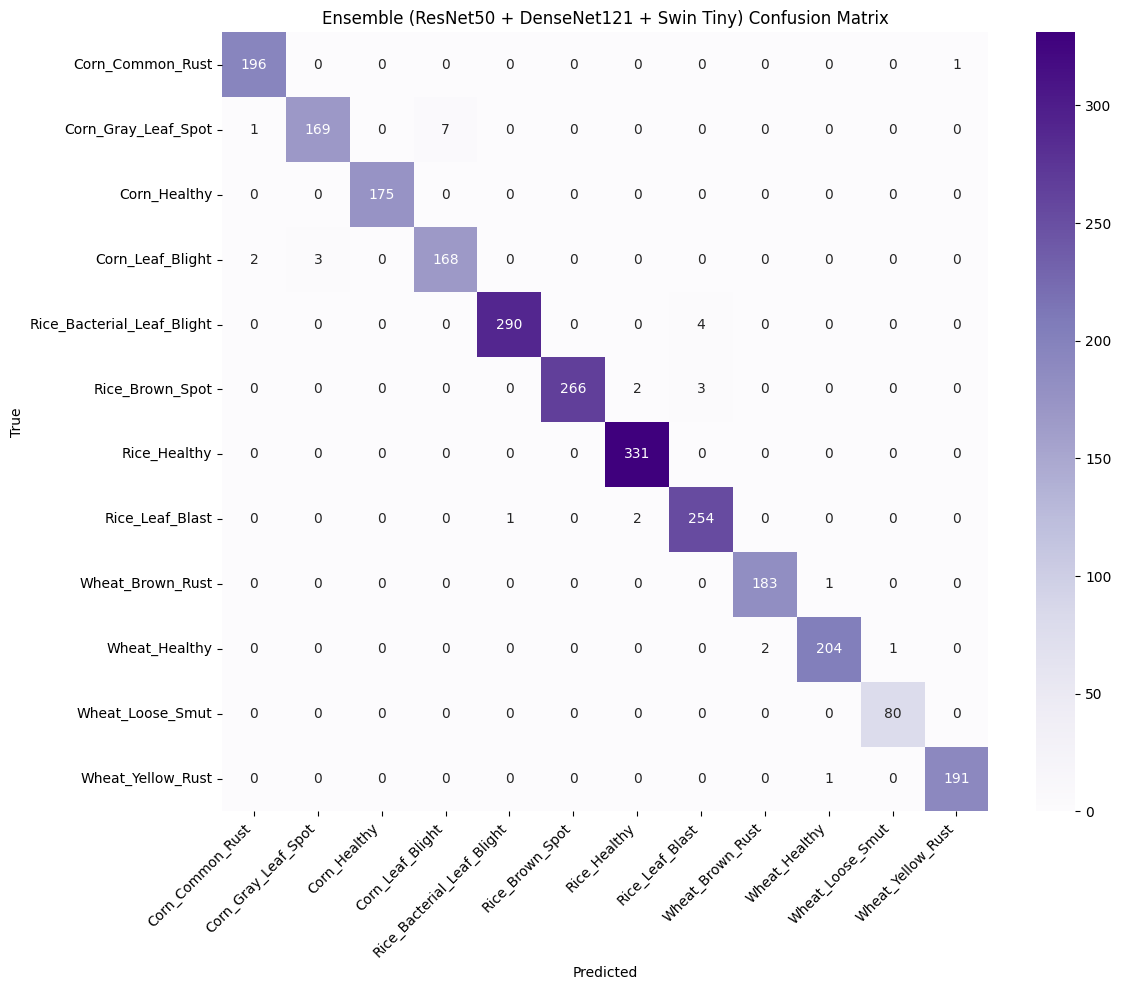

Results saved to: /content/drive/MyDrive/thesis_ensemble_outputs


In [17]:
output_folder = '/content/drive/MyDrive/thesis_ensemble_outputs'
os.makedirs(output_folder, exist_ok=True)

with open(f'{output_folder}/ensemble_resnet_densenet_swin_report.txt', 'w') as f:
    f.write(f"ResNet50 accuracy: {acc_resnet:.4f}\n")
    f.write(f"DenseNet121 accuracy: {acc_densenet:.4f}\n")
    f.write(f"Swin Tiny accuracy: {acc_swin:.4f}\n")
    f.write(f"Ensemble (simple average) accuracy: {acc_ensemble:.4f}\n")
    f.write(f"Best weighted combo [w_resnet, w_densenet, w_swin] (tuned on val set): {best_w}\n")
    f.write(f"Ensemble (weighted) test accuracy: {acc_ensemble_weighted:.4f}\n\n")
    f.write(report)

cm = confusion_matrix(true_labels, ensemble_preds)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names, cmap='Purples')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Ensemble (ResNet50 + DenseNet121 + Swin Tiny) Confusion Matrix')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(f'{output_folder}/ensemble_resnet_densenet_swin_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Results saved to: {output_folder}")